In [5]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import matplotlib
import texplot
import matplotlib.ticker as mticker
from pprint import pprint

import freealg
from freealg import AlgebraicForm
from freealg.visualization import plot_flow, plot_mass, ridgeplot, plot_edges
from freealg.visualization._api_plot_util import _k_pow2_formatter

plot_dir = './plots'
latex = True

In [6]:
config1 = dict(
    # input_filename = 'hessian120k16k_eigs.npz',
    input_filename = 'hessian120k16k_eigs_half.npz',  # half powers of 2
    deg_m = 3,
    effective_n = 80_000,
    xlim = (0, 0.8),
    ylim = [(0, 20), (0, 20), (0, 7)],
    nbins = (80, 400),
    label_mode = 'pow-dec',
    save_filename = 'hessian120k16k',
)

# Homogeneous version of config1. It has one bulk
# config2 = dict(
#     input_filename = 'hessian120k16khomo_eigs.npz',
#     deg_m = 3,
#     effective_n = 80_000,
#     xlim = (0, 0.8),
#     ylim = [(0, 19), (0, 19), (0, 7)],
#     nbins = (80, 200),
#     label_mode = 'pow-int',
#     save_filename = 'hessian120k16khomo',
# )

config3 = dict(
    input_filename = 'hessian2100k32k_eigs.npz',
    deg_m = 4,
    effective_n = 25_000,
    xlim = (-0.03, 0.6),
    ylim = [(0, 30), (0, 30), (0, 15)],
    nbins = (80, 1000),
    label_mode = 'pow-int',
    save_filename = 'hessian2100k32k',
)

# -------

# config = config1
# config = config2
config = config3

Idx   Size
---  -----
0     1000
1     2000
2     4000
3     8000
4    16000
5    32000



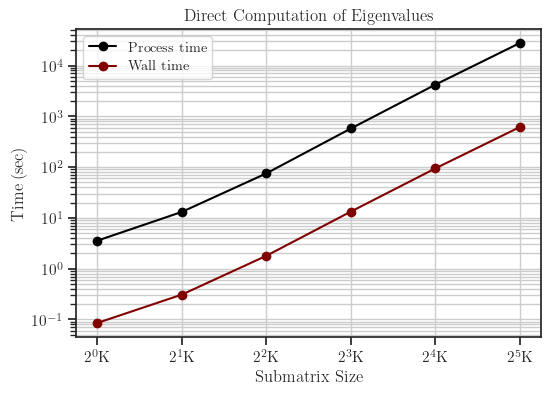

In [7]:
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, config['input_filename']), allow_pickle=True)
out = data['out'].item()

sizes = out['sizes']
eigs = out['eigs']
wall_times = out['wall_times']
proc_times = out['proc_times']
n, p = out['shape']

# Sizes of submatrices
print('Idx   Size')
print('---  -----')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}')
print('')
# print(f'proc name: {proc_name}')
# print(f'num proc:  {num_proc}')
# print(f'date:      {date}')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

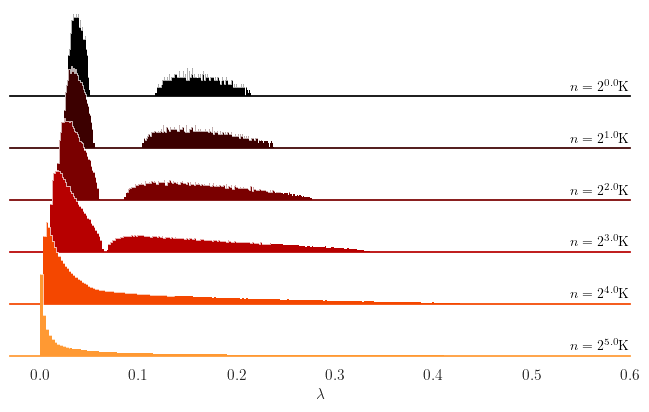

In [4]:
eigs_no_atom = [None] * len(eigs)
tol = 1e-4
for i in range(len(eigs)):
    eigs_no_atom[i] = eigs[i][numpy.abs(eigs[i]) > tol]

ridgeplot(sizes, eigs=eigs_no_atom, log=False, scaley=True, hspace=-0.4,
          text_side='right', xlim=config['xlim'], ylim=None, figsize=(8, 4.5),
          # label_mode='pow-int',
          label_mode='pow-dec',
          latex=latex, title='',
          save=False, nbins=200)

# Fit Spectral Curves

In [8]:
# Index to choose the initial sub-matrix size
start_idx = 0

# Detect support from histogram
print('\n------------------------------------------')
print('Support (detected from histogram):')
support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=False,
                      print_info=True)

# Stieltjes options
stieltjes_opt = dict(
    n_levels = 200,
    max_subdivide = 20,
    anchor_mode = 'asymptote',   # empirical, asymptotic
    anchor_y_min = 1e-4,  # 1e-5~1e-6 cause left bulks to fail
    anchor_y_max = 1,
    anchor_ratio = 0.01,  # 0.1~1 cause stieltjes_emp to not latch to poly roots
    # anchor_match_tol = numpy.inf,  # disables anchor retry
    # anchor_ratio_tol = numpy.inf,
    anchor_match_tol = 0.1,       # retry if init anchor not mathc roots
    anchor_ratio_tol = 0.9,
    anchor_retry_factor = 3.0     # factor to multiple anchor height in retrial
)

# Inverse Stieltjes options
inv_stieltjes_opt = dict(
    delta = 1e-5,
    delta_ladder_ratio = 2.0,
    delta_ladder_size = 4,
    delta_ladder_grid = 'linear',   # geometric, linear
    z_query_delta = 'const',       # const, linear
    method = 'chebfit',             # direct, polyfit, chebfit, poisson
    fit_degree = 2,
    reg = 0.0,
    fit_weight = 'uniform',  # 'uniform, small_delta
)

# Estimate the initia ratio "c0" from "c" of the larger matrix
ratio = sizes[start_idx] / config['effective_n']

# Main object
af = AlgebraicForm(eigs[start_idx],
                   ratio=ratio,
                   support=None,
                   # support=support,
                   n=sizes[start_idx],
                   log=False,
                   dtype='complex128',
                   stieltjes_opt=stieltjes_opt,
                   inv_stieltjes_opt=inv_stieltjes_opt)

# Polynomial degrees
deg_m = config['deg_m']
deg_z = 2

# Moments to be used as constraints in fitting
deg_mu = 2
mu = numpy.zeros((deg_mu+1, ), dtype=float)
mu[0] = 1.0
for i in range(1, mu.size):
    if i == 1:
        mu[i] = numpy.mean(af.eig)
    else:
        mu[i] = numpy.mean(af.eig**i)

print('\n------------------------------------------')
coeffs = af.fit(
    deg_m, deg_z, reg=0,
    r_min=1.8, r_max=2.2, n_r=5,
    y_scale=1.0, gamma=1.0,
    n_samples=4096,
    cut_eps=0.01,
    normalize=True,
    triangular=None,
    # triangular=(-1, 1),
    mu=mu,
    # mu='auto',
    mu_reg=None, verbose=True, plot=False)

# print('\n------------------------------------------')
# print('Support (estimated from polynomial):')
# est_supp = af.support()
# for i, supp in enumerate(est_supp):
#     print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# print('\n------------------------------------------')
# print('Atoms (estimated from polynomial):')
# for i, atom in enumerate(af.atoms()):
#     print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, weight: {100.0*atom[1]:>4.1f}%')


------------------------------------------
Support (detected from histogram):
| bulk 1 | interval: (  0.02908,   0.05164) | center:   0.04036 |  mass: 46.50% |
| bulk 2 | interval: (  0.11683,   0.21587) | center:   0.16635 |  mass: 53.50% |
mass(x) ~ 0.4426 + 0.5556 * x

------------------------------------------
fit residual max  : 4.8612e-07
fit residual 99.9%: 4.8605e-07

Coefficients (real)
+0.08462262 -0.00153633 -0.00027722 +0.00000151 +0.00000000 
-0.91537738 +0.13052505 +0.00876128 -0.00002722 -0.00000029 
+0.00000000 -0.91537738 -0.05024413 -0.00010225 +0.00000263 

Coefficients (imag) norm: 0.0000e+00


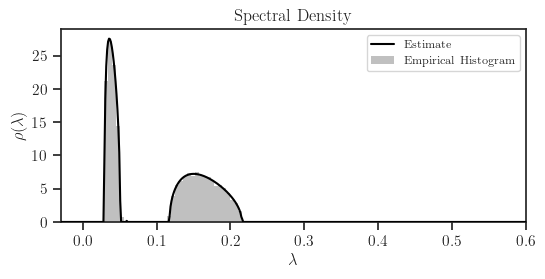

mass: 1.001584


In [6]:
x_min, x_max = config['xlim']
x0 = numpy.linspace(x_min, x_max, 500)
rho0 = af.density(x0, plot=True, latex=latex)

mass = numpy.trapz(rho0, x0)
print('mass: %f' % mass)

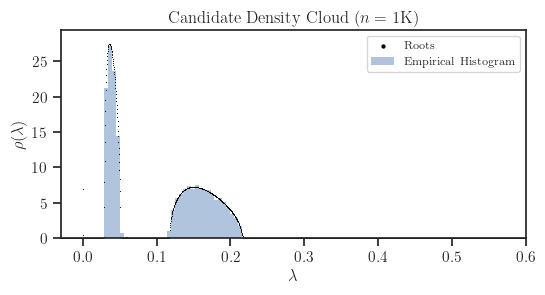

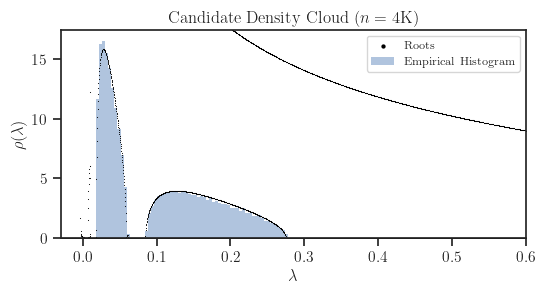

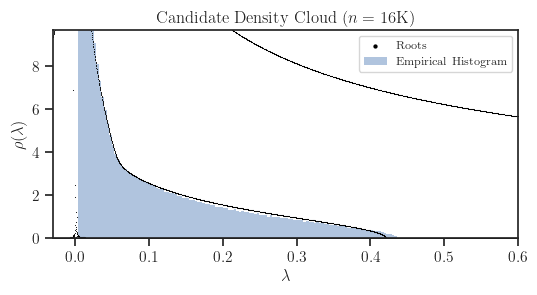

In [6]:
# Check if the density plotted above is formed by correct roots. For this,
# we plot all possible roots below.
x_min, x_max = config['xlim']
x_highres = numpy.linspace(x_min, x_max, 2000)

# for idx in [start_idx, start_idx+1, sizes.size-1]:
for idx in range(start_idx, sizes.size, 2):
    # ylim = (0, 0.06) if idx == sizes.size - 1 else None
    e = eigs[idx]
    h = numpy.histogram(e, 100, density=True)[0]
    ylim = (0, 1.1 * float(numpy.max(h[5:])))
    af.candidates(
        size=sizes[idx],
        kind='deformed',
        x=x_highres,
        eig=eigs[idx],
        delta=None, markersize=0.6,
        ylim=ylim, latex=latex)

success rate per t: [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         0.99599198 1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.

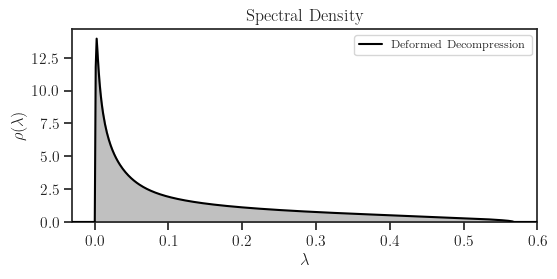

In [9]:
end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]

x_min, x_max = config['xlim']
x = numpy.linspace(x_min, x_max, 500)

# Settigns for _deform5.py
# newton_opt = dict(
#     dt_max=0.02,
# )

# # TEST
# inv_stieltjes_opt = dict(
#     delta = 1e-5,
#     delta_ladder_ratio = 2.0,
#     delta_ladder_size = 1,
#     delta_ladder_grid = 'linear',   # geometric, linear
#     z_query_delta = 'const',       # const, linear
#     method = 'direct',             # direct, polyfit, chebfit, poisson
#     fit_degree = 2,
#     reg = 0.0,
#     fit_weight = 'uniform',  # 'uniform, small_delta
# )
# af.inv_stieltjes_opt = inv_stieltjes_opt
# af.delta_ladder_grid = numpy.array([1e-5])

# Settings for _deform10_6d.py
newton_opt = dict(
    dt_max=0.005,
    dt_min=1e-10,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=False,
    pair_enable=True,
    pair_gap_factor=10.0,
)

rho = af.decompress(
    fd_sizes, x=x, kind='deformed', method='moc',
    # min_n_times=0,
    min_n_times=100,
    newton_opt=newton_opt, return_atoms=False,
    atom_eps=0, verbose=True, plot=True, latex=latex)

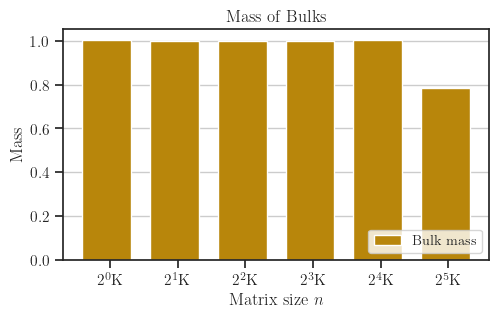

In [8]:
plot_mass(fd_sizes, x, rho, atoms=None, log_x=True, gap=0.7, save=False, latex=latex)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/hessian2100k32k-flow.pdf".


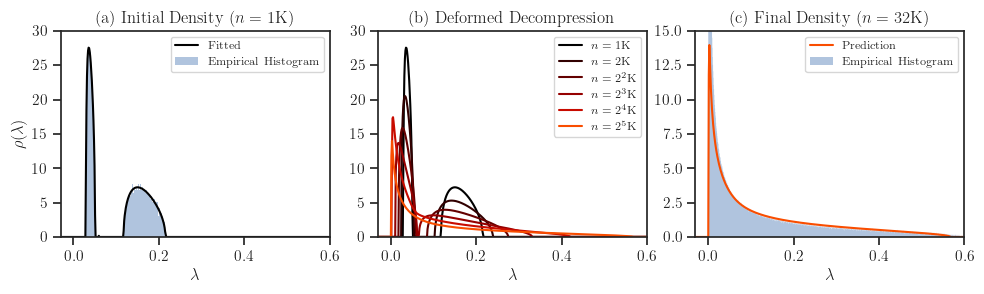

In [10]:
plot_flow(fd_sizes, x, rho, eigs[start_idx], eigs[end_idx], xlim=config['xlim'],
          ylim=config['ylim'], share_ax=False, layout='horizontal', title='Deformed Decompression',
          cmap=plt.cm.gist_heat,
          c_range=(0.0, 0.65),
          hist_color='lightsteelblue',
          nbins=config['nbins'],
          label_mode=config['label_mode'],
          save=join(plot_dir, config['save_filename'] + '-flow.pdf'),
          latex=latex)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/hessian2100k32k-ridge.pdf".


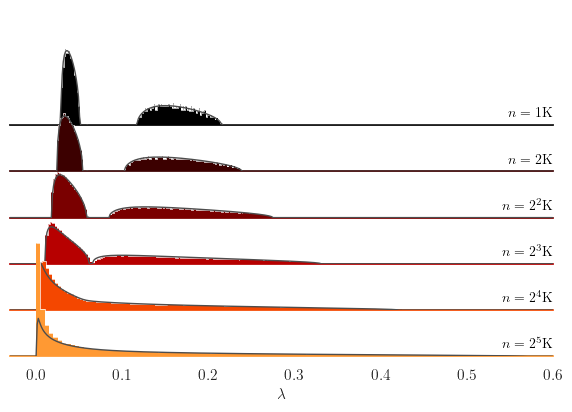

In [10]:
# Set zero density to be slihtly below axis to show background axis
rho_ = numpy.copy(rho)
rho_[rho_ < 5e-3] = -5e-3

ridgeplot(fd_sizes, x=x, rho=rho_, eigs=eigs,
          text_side='right',
          hspace=-0.6, figsize=(7, 4.5),
          scaley=False, ylim_factor=1.0,
          xlim=config['xlim'], rho_color='0.3',
          nbins=120,
          label_mode=config['label_mode'],
          # save=False,
          save=join(plot_dir, config['save_filename'] + '-ridge.pdf'),
          latex=latex)

# Edge

In [11]:
# fd_sizes = numpy.arange(As.shape[0], A.shape[0]+1, 500)
# base = 1000
# fd_sizes = base * 2**(numpy.arange(numpy.log2(As.shape[0]/base),
#                                    numpy.log2(A.shape[0]/base)+0.01, 0.5))
# start_idx = 0
# end_idx = fd_sizes.size - 1

end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]

t_final = numpy.log(fd_sizes[-1] / fd_sizes[0])
t = numpy.linspace(0, t_final, 200)

# cusps, info = af.cusp(t, kind='deformed', supp=support, max_iter=200, tol=1e-8,
#                       dedup_t_tol=1e-6, dedup_x_tol=1e-6, return_info=True)

# est_supp = af.support(return_info=False)
# print(est_supp)

support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=False,
                      print_info=True)

real_merged_edges, cusps = af.edge(
    t, kind='deformed',
    supp=support,
    # supp=est_supp,
    dt_max=0.01, max_iter=100, tol=1e-12)

print('Cusps:')
if len(cusps) > 0:
    for cusp in cusps:
        print(f'\tx: {cusp[0]:>0.3f}, t: {cusp[1]:>0.3f}')

| bulk 1 | interval: (  0.02908,   0.05164) | center:   0.04036 |  mass: 46.50% |
| bulk 2 | interval: (  0.11683,   0.21587) | center:   0.16635 |  mass: 53.50% |
mass(x) ~ 0.4426 + 0.5556 * x
Cusps:
	x: 0.061, t: 2.300


Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/hessian2100k32k-edge.pdf".


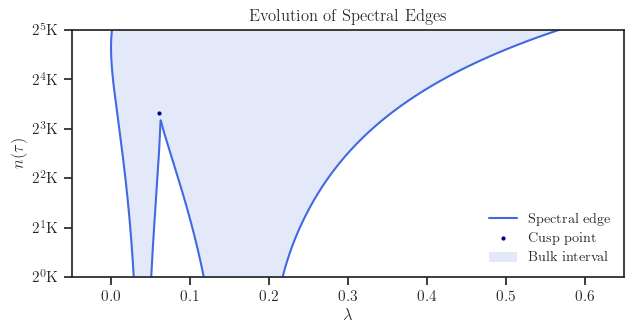

In [12]:
plot_edges(t, real_merged_edges,
           cusps=cusps, sizes=fd_sizes,
           # sizes=None,
           edge_color='royalblue', fill_color='royalblue', alpha=0.14,
           figsize=None, annotate=False, xlim=(-0.05, 0.65), log_x=False, log_y=True,
           flip_y=False,
           save=join(plot_dir, config['save_filename'] + '-edge.pdf'), latex=latex)

In [13]:
fd_sizes_plot = numpy.geomspace(sizes[start_idx], sizes[end_idx], t.size)

rho_plot = af.decompress(
    fd_sizes_plot, x=x, kind='deformed', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=False,
    atom_eps=0, verbose=False, plot=False, latex=False)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/hessian2100k32k-edge2.pdf".


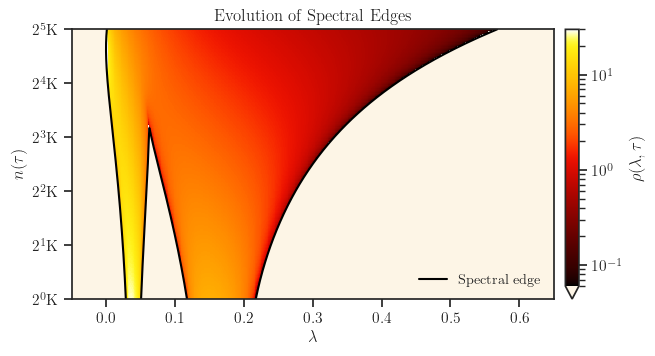

In [14]:
import colorcet as cc

t_ = sizes[start_idx] * numpy.exp(t)
xx, tt_ = numpy.meshgrid(x, t_)

# poisson = (af.delta / numpy.pi) / (xx**2 + af.delta**2)
r = numpy.copy(rho_plot)
# r = numpy.abs(r)
# r[r < poisson] = numpy.nan
# r[r < poisson] = poisson[r < poisson]

# r[(r < 1e-7) & numpy.logical_not(near_cusp)] = numpy.nan
# r[(numpy.abs(r) < 1e-7)] = numpy.nan
r[r < 6e-2] = numpy.nan

# Repair nan points very close to cusp
near_cusp = (xx < 0.08) & (xx > 0.02) & (tt_ < 6000)
repair = near_cusp & (r < 5e-1)
r[repair] = numpy.nan
# r[repair] = 1e2 # poisson[repair]
# r[(xx < left_edges[:, None])] = numpy.nan


# t_emp = numpy.log(sizes[start_idx:end_idx+1] / sizes[start_idx])
# t_emp = sizes[start_idx:end_idx+1]
# e_emp = min_eigs[start_idx:end_idx+1]

# cmap = plt.cm.YlOrBr; c_range = (0, 0.95)
# cmap = plt.cm.afmhot; c_range = (0, 0.82)
# cmap = plt.cm.gist_heat; c_range = (0.05, 0.95)
# cmap = plt.cm.YlOrRd; c_range = (0, 1)
# cmap = cc.cm.CET_CBL3; c_range = (0.1, 1)# blue black
# cmap = cc.cm.CET_L20; c_range = (0.1, 1)  # no
# cmap = cc.cm.CET_L16; c_range = (0.3, 0.99)
cmap = cc.cm.CET_L3; c_range = (0.0, 1.0) 
# cmap = cc.cm.CET_R2_r; c_range = (0.05, 0.7)
# cmap = cc.cm.CET_R1_r; c_range = (0.2, 0.9)

# cmap_trim = cmap.from_list('trimmed', cmap(numpy.linspace(0.2, 0.9, 256)))
cmap_trim = cmap.from_list('trimmed', cmap(numpy.linspace(c_range[0], c_range[1], 256)))

plot_edges(t, real_merged_edges,
           # cusps=cusps,
           cusps=None,
           sizes=fd_sizes,
           x=x, rho=r, cbar_range=(6e-2, 30), cbar_log=True, cmap=cmap_trim,
           bg_color='oldlace', edge_color='black', fill_color='royalblue', alpha=0.14,
           figsize=(6.8, 3.725), annotate=False, annotate_color='0.3',
           xlim=(-0.05, 0.65), log_x=False, log_y=True, flip_y=False,
           save=join(plot_dir, config['save_filename'] + '-edge2.pdf'), latex=latex)

# Tables

In [15]:
# ================
# set delta_ladder
# ================

def set_delta_ladder(delta_ladder_size, method, fit_degree=2):
    """
    To benchmakr with only ont evaluation of density at one
    delta distance, set af.delta_ladder, like

    >>> set_delta_ladder(delta_ladder_size=1, method='direct', fit_degree=2)

    To return back to previosu behavior, set

    >>> set_delta_ladder(delta_ladder_size=4, method='chebfit', fit_degree=2)
    """
    
    af.inv_stieltjes_opt['delta_ladder_size'] = delta_ladder_size
    af.inv_stieltjes_opt['method'] = method
    af.inv_stieltjes_opt['fit_degree'] = fit_degree
        
    delta_ladder_grid = inv_stieltjes_opt['delta_ladder_grid']
    delta_ladder_ratio = inv_stieltjes_opt['delta_ladder_ratio']
    delta_ladder_size = inv_stieltjes_opt['delta_ladder_size']
    
    # Type of grid to produces multiple deltas for Plemelj
    if delta_ladder_grid == 'geometric':
        af.delta_ladder = af.delta * (
                delta_ladder_ratio **
                numpy.arange(delta_ladder_size, dtype=int))
    elif delta_ladder_grid == 'linear':
        af.delta_ladder = af.delta * \
            numpy.arange(1, delta_ladder_size+1, dtype=int)

    print('\nChanged af.delta_ladder to:')
    print(af.delta_ladder)
    print('')

# Runtime

To correctly measure runtime, do these:

1. `ssh mm340`
2. Export these
   ```
       export OMP_NUM_THREADS=1
       export OPENBLAS_NUM_THREADS=1
       export MKL_NUM_THREADS=1
       export NUMEXPR_NUM_THREADS=1
   ```
3. In `newton_opt`, set
   ```
       parallel=False
       n_jobs=1
   ```

In [26]:
import time, resource

def cpu_total_with_children():
    self = resource.getrusage(resource.RUSAGE_SELF)
    kids = resource.getrusage(resource.RUSAGE_CHILDREN)
    return self.ru_utime + self.ru_stime + kids.ru_utime + kids.ru_stime

# Copy settigns so we can revert it later
orig_delta_ladder_size = af.inv_stieltjes_opt['delta_ladder_size']
orig_method = af.inv_stieltjes_opt['method']
orig_fit_degree = af.inv_stieltjes_opt['fit_degree']

set_delta_ladder(delta_ladder_size=1, method='direct')

# Choosing the largest sub-matrix size to decompress to
end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
x_min, x_max = config['xlim']
x = numpy.linspace(x_min, x_max, 500)

newton_opt = dict(
    dt_max=0.005,
    dt_min=1e-10,
    tol=1e-8,
    max_iter=1000,
    parallel=False,
    n_jobs=1,
    log_mode=False,
    pair_enable=True,
    pair_gap_factor=10.0,
)

repeats = 5
fd_wall_times = numpy.zeros((fd_sizes.size,), dtype=float)
fd_proc_times = numpy.zeros((fd_sizes.size,), dtype=float)

i=0
print(f'Size: {fd_sizes[i]:>5d} ' + '.'*repeats, end='')
print(f' | fd wall time: {fd_wall_times[i]:>6.1f}'
      f' | fd proc time: {fd_proc_times[i]:>6.1f}'
      f' | direct proc time: {proc_times[i]:>9.1f}')

for i in numpy.arange(1, fd_sizes.size):

    print(f'Size: {fd_sizes[i]:>5d} ', end='')

    for j in range(repeats):

        print(f'.', end='')

        init_wall_time = time.time()
        init_proc_time = cpu_total_with_children()
        # init_proc_time = time.process_time()

        min_n_times = int(100 * fd_sizes[i] / fd_sizes[-1])
        
        rho_bnch = af.decompress(
            fd_sizes[0:i+1], x=x, kind='deformed', method='moc', min_n_times=min_n_times,
            newton_opt=newton_opt, return_atoms=False, atom_eps=0,
            verbose=False, plot=False, latex=latex)

        fd_wall_times[i] += time.time() - init_wall_time
        fd_proc_times[i] += cpu_total_with_children() - init_proc_time
        # fd_proc_times[i] += time.process_time() - init_proc_time

    fd_wall_times[i] /= repeats
    fd_proc_times[i] /= repeats

    print(f' | fd wall time: {fd_wall_times[i]:>6.1f}'
          f' | fd proc time: {fd_proc_times[i]:>6.1f}'
          f' | direct proc time: {proc_times[start_idx+i]:>9.1f}')

# Revert back to the original setting 
af.inv_stieltjes_opt['delta_ladder_size'] = orig_delta_ladder_size
af.inv_stieltjes_opt['method'] = orig_method
af.inv_stieltjes_opt['fit_degree'] = orig_fit_degree
set_delta_ladder(orig_delta_ladder_size, orig_method)


Changed af.delta_ladder to:
[1.e-05]

Size:  1000 ..... | fd wall time:    0.0 | fd proc time:    0.0 | direct proc time:       3.6
Size:  2000 ..... | fd wall time:    0.8 | fd proc time:    1.0 | direct proc time:      13.1
Size:  4000 ..... | fd wall time:    2.1 | fd proc time:    2.3 | direct proc time:      75.3
Size:  8000 ..... | fd wall time:    4.5 | fd proc time:    4.7 | direct proc time:     576.7
Size: 16000 ..... | fd wall time:    9.0 | fd proc time:    9.2 | direct proc time:    4221.8
Size: 32000 ..... | fd wall time:   18.4 | fd proc time:   18.6 | direct proc time:   27897.1

Changed af.delta_ladder to:
[1.e-05]



# Distributional Comparison (Table)

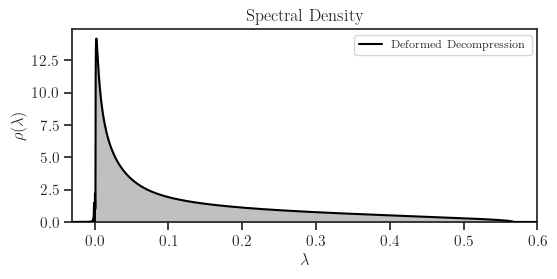

In [27]:
# Choosing the largest sub-matrix size to decompress to
end_idx = sizes.size - 1

# Subset of sizes to apply free decompression
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
x_min, x_max = config['xlim']
x = numpy.linspace(x_min, x_max, 2000)

newton_opt = dict(
    dt_max=0.005,
    dt_min=1e-10,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=False,
    pair_enable=True,
    pair_gap_factor=10.0,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho, atoms = af.decompress(
    fd_sizes, x=x, kind='deformed', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)

In [29]:
rho_cut = rho.copy()
# for i in range(rho_cut.shape[0]):
#     rho_cut[i, x < numpy.min(eigs[start_idx + i])] = 0.0

In [30]:
import numpy
from scipy.stats import ks_2samp, wasserstein_distance
from freealg import sample


# def sample_tv_log(eig_emp, eig_fd, bins=150, xrange=None):
#     """Histogram-based TV using log-spaced bins."""
#     if xrange is None:
#         lo = max(min(eig_emp.min(), eig_fd.min()), numpy.finfo(float).tiny)
#         hi = max(eig_emp.max(), eig_fd.max())
#     else:
#         lo, hi = xrange

#     eig_emp = eig_emp[(eig_emp >= lo) & (eig_emp <= hi)]
#     eig_fd = eig_fd[(eig_fd >= lo) & (eig_fd <= hi)]

#     edges = numpy.geomspace(lo, hi, bins + 1)

#     hist_emp, edges = numpy.histogram(eig_emp, bins=edges, density=True)
#     hist_fd, _ = numpy.histogram(eig_fd, bins=edges, density=True)

#     dx = numpy.diff(edges)
#     return 0.5 * numpy.sum(numpy.abs(hist_emp - hist_fd) * dx)

def sample_tv(eig_emp, eig_fd, bins=150, xrange=None):
    """Histogram-based TV using linearly spaced bins."""
    if xrange is None:
        lo = min(eig_emp.min(), eig_fd.min())
        hi = max(eig_emp.max(), eig_fd.max())
    else:
        lo, hi = xrange

    eig_emp = eig_emp[(eig_emp >= lo) & (eig_emp <= hi)]
    eig_fd = eig_fd[(eig_fd >= lo) & (eig_fd <= hi)]

    edges = numpy.linspace(lo, hi, bins + 1)

    hist_emp, edges = numpy.histogram(eig_emp, bins=edges, density=True)
    hist_fd, _ = numpy.histogram(eig_fd, bins=edges, density=True)

    dx = numpy.diff(edges)
    return 0.5 * numpy.sum(numpy.abs(hist_emp - hist_fd) * dx)


def density_moment(rho_i, x, k):
    """Compute unnormalized int x^k rho(x) dx."""
    return numpy.trapz((x**k) * rho_i, x)


def gaussian_mmd2_biased(a, b, sigma=None, max_pts=4000, seed=0):
    """Biased Gaussian MMD^2. Returns value in [0, 2]."""
    rng = numpy.random.default_rng(seed)

    a = numpy.asarray(a)
    b = numpy.asarray(b)

    if a.size > max_pts:
        a = rng.choice(a, size=max_pts, replace=False)
    if b.size > max_pts:
        b = rng.choice(b, size=max_pts, replace=False)

    a = a[:, None]
    b = b[:, None]

    if sigma is None:
        z = numpy.vstack([a, b]).ravel()
        dz = numpy.abs(z[:, None] - z[None, :])
        sigma = numpy.median(dz[dz > 0])
        if not numpy.isfinite(sigma) or sigma <= 0:
            sigma = 1.0

    k_aa = numpy.exp(-0.5 * ((a - a.T) / sigma)**2).mean()
    k_bb = numpy.exp(-0.5 * ((b - b.T) / sigma)**2).mean()
    k_ab = numpy.exp(-0.5 * ((a - b.T) / sigma)**2).mean()

    return k_aa + k_bb - 2.0 * k_ab


tv = []
ks = []
w1 = []
w1_norm = []
mmd = []
mu1_err = []
mu2_err = []
std_err = []

for j, n in enumerate(fd_sizes):
    eig_emp = numpy.asarray(eigs[start_idx + j])
    rho_fd = rho_cut[j]

    eig_fd = sample(
        x, rho_fd,
        num_pts=eig_emp.size,
        method='qmc',
        seed=start_idx + j,
    )

    # tv_i = sample_tv_log(
    #     eig_emp, eig_fd,
    #     bins=450,
    #     xrange=(numpy.min(eig_emp), numpy.max(eig_emp)),
    # )

    # ks_i = ks_2samp(eig_emp, eig_fd).statistic

    # log_emp = numpy.log(eig_emp[eig_emp > 0])
    # log_fd = numpy.log(eig_fd[eig_fd > 0])

    # w1_i = wasserstein_distance(eig_emp, eig_fd)
    # log_L_i = numpy.ptp(log_emp)
    # w1_norm_i = wasserstein_distance(log_emp, log_fd) / log_L_i

    # # MMD on log eigenvalues; report MMD^2 / 2 as a [0, 1]-scaled number.
    # mmd_i = 0.5 * gaussian_mmd2_biased(
    #     log_emp, log_fd, sigma=None, max_pts=4000, seed=start_idx + j)

    tv_i = sample_tv(
        eig_emp, eig_fd,
        bins=450,
        xrange=(numpy.min(eig_emp), numpy.max(eig_emp)),
    )

    ks_i = ks_2samp(eig_emp, eig_fd).statistic

    w1_i = wasserstein_distance(eig_emp, eig_fd)
    L_i = numpy.ptp(eig_emp)
    w1_norm_i = w1_i / L_i

    # MMD on eigenvalues; report MMD^2 / 2 as a [0, 1]-scaled number.
    mmd_i = 0.5 * gaussian_mmd2_biased(
        eig_emp, eig_fd, sigma=None, max_pts=4000, seed=start_idx + j)

    mu1_emp = numpy.mean(eig_emp)
    mu2_emp = numpy.mean(eig_emp**2)
    std_emp = numpy.std(eig_emp)

    mu1_fd = density_moment(rho_fd, x, 1)
    mu2_fd = density_moment(rho_fd, x, 2)
    std_fd = numpy.sqrt(mu2_fd - mu1_fd**2)

    mu1_err_i = numpy.abs(mu1_fd - mu1_emp) / numpy.abs(mu1_emp)
    mu2_err_i = numpy.abs(mu2_fd - mu2_emp) / numpy.abs(mu2_emp)
    std_err_i = numpy.abs(std_fd - std_emp) / numpy.abs(std_emp)

    tv.append(tv_i)
    ks.append(ks_i)
    w1.append(w1_i)
    w1_norm.append(w1_norm_i)
    mmd.append(mmd_i)
    mu1_err.append(mu1_err_i)
    mu2_err.append(mu2_err_i)
    std_err.append(std_err_i)

tv = numpy.asarray(tv)
ks = numpy.asarray(ks)
w1 = numpy.asarray(w1)
w1_norm = numpy.asarray(w1_norm)
mmd = numpy.asarray(mmd)
mu1_err = numpy.asarray(mu1_err)
mu2_err = numpy.asarray(mu2_err)
std_err = numpy.asarray(std_err)

print(
    f"{'n':>6}  {'TV':>6}  {'KS':>6}  {'W1/L':>7}  {'MMD':>7}  "
    f"{'mu1 err':>8}  {'mu2 err':>8}  {'std err':>8}"
)
print("-" * 70)

for j, n in enumerate(fd_sizes):
    print(
        f"{int(n):6d}  "
        f"{100*tv[j]:5.1f}%  "
        f"{100*ks[j]:5.1f}%  "
        f"{100*w1_norm[j]:6.2f}%  "
        f"{100*mmd[j]:6.2f}%  "
        f"{100*mu1_err[j]:7.2f}%  "
        f"{100*mu2_err[j]:7.2f}%  "
        f"{100*std_err[j]:7.2f}%"
    )

     n      TV      KS     W1/L      MMD   mu1 err   mu2 err   std err
----------------------------------------------------------------------
  1000    8.9%    0.3%    0.04%    0.00%     0.00%     0.01%     0.03%
  2000    6.9%    1.8%    1.01%    0.02%     2.15%     3.00%     0.07%
  4000    5.2%    2.4%    1.19%    0.03%     2.86%     3.78%     0.05%
  8000    4.8%    3.6%    1.42%    0.05%     4.36%     5.60%     0.45%
 16000    4.7%    2.5%    1.19%    0.05%     4.14%     4.51%     0.37%
 32000   18.1%   17.5%    5.63%    1.31%     4.24%     3.76%     0.47%


### Error of Edges

In [34]:
# real_merged_edges_clean = numpy.delete(real_merged_edges, [5, 6], axis=1)
real_merged_edges_clean = numpy.copy(real_merged_edges)
t_fd = numpy.log(fd_sizes / fd_sizes[0])

all_edge_err = []
mean_edge_err = []
max_edge_err = []

print(f"{'n':>6}  {'mean err':>9}  {'max err':>8}  {'edge errors'}")
print("-" * 72)

for j, n in enumerate(fd_sizes):
    eig_emp = numpy.asarray(eigs[start_idx + j])

    supp_j = freealg.supp(
        eig_emp,
        method='hist',
        tol=0,
        nbins=150,
        log=False,
        print_info=False,
    )

    emp_edges = numpy.array([v for interval in supp_j for v in interval])
    emp_edges = numpy.sort(emp_edges)

    k = numpy.argmin(numpy.abs(t - t_fd[j]))
    fd_edges = real_merged_edges_clean[k]
    fd_edges = fd_edges[numpy.isfinite(fd_edges)]
    fd_edges = numpy.sort(fd_edges)

    # Drop leftmost edge of spike bulk from both sets.
    # emp_edges = emp_edges[1:]
    # fd_edges = fd_edges[1:]

    matched_fd = []
    err = []

    # for emp_edge in emp_edges:
    #     q = numpy.argmin(numpy.abs(numpy.log(fd_edges) - numpy.log(emp_edge)))
    #     fd_edge = fd_edges[q]
    #     matched_fd.append(fd_edge)

    #     log_xrange = numpy.log(x[-1]) - numpy.log(x[0])
    #     err.append(numpy.abs(numpy.log(fd_edge) - numpy.log(emp_edge)) / log_xrange)
    #     # err.append(numpy.abs(fd_edge - emp_edge) / numpy.abs(emp_edge))

    xrange = x[-1] - x[0]

    for emp_edge in emp_edges:
        q = numpy.argmin(numpy.abs(fd_edges - emp_edge))
        fd_edge = fd_edges[q]
        matched_fd.append(fd_edge)

        err.append(numpy.abs(fd_edge - emp_edge) / xrange)
        # alternative:
        # err.append(numpy.abs(fd_edge - emp_edge) / numpy.abs(emp_edge))

    err = numpy.asarray(err)

    all_edge_err.append(err)
    mean_edge_err.append(numpy.mean(err))
    max_edge_err.append(numpy.max(err))

    err_str = ", ".join([f"{100*e:.1f}%" for e in err])

    print(
        f"{int(n):6d}  "
        f"{100*mean_edge_err[-1]:8.1f}%  "
        f"{100*max_edge_err[-1]:7.1f}%  "
        f"{err_str}"
    )

mean_edge_err = numpy.asarray(mean_edge_err)
max_edge_err = numpy.asarray(max_edge_err)

     n   mean err   max err  edge errors
------------------------------------------------------------------------
  1000       0.1%      0.2%  0.0%, 0.1%, 0.1%, 0.2%
  2000       0.1%      0.3%  0.0%, 0.3%, 0.0%, 0.2%
  4000       0.2%      0.5%  0.0%, 0.5%, 0.0%, 0.4%
  8000       0.4%      1.1%  0.1%, 0.1%, 0.3%, 1.1%
 16000       1.3%      2.5%  0.2%, 2.5%
 32000       2.8%      5.4%  0.2%, 5.4%


# Candidtaes

In [54]:
from freealg._algebraic_form._deform_coeffs2 import deform_coeffs, plot_deform_candidates

# =========================
# plot candidate comparison
# =========================

def plot_candidate_comparison(x_cand, coeffs_i, x_rho, rho, bins, eigs, xlim, ylim,
                              suffix, cut=None, rho2=None):

    with texplot.theme(use_latex=latex):
        if rho2 is None:
            fig, ax = plt.subplots(figsize=(8, 2.8), ncols=2)
        else:
            fig, ax = plt.subplots(figsize=(10, 2.8), ncols=3, sharey=True)
        
        plot_deform_candidates(coeffs_i, x_cand, ax=ax[0], eig=eigs, delta=af.delta,
                               size=int(alpha*af.n),
                               log=af._log,
                               markersize=0.6, ylim=ylim,
                               latex=latex, verbose=True)

        poisson = (af.delta / numpy.pi) / (af.delta**2 + x**2)

        if rho2 is not None:
            rho2[rho2 < poisson] = 0.0

        if cut is not None:
            rho[x_rho < cut] = numpy.nan

            if rho2 is not None:
                rho2[x_rho < cut] = numpy.nan
    
        ax[1].plot(x_rho, rho, color='black', label='Physical density')
        # ax[1].hist(eigs, bins=bins, density=True, color='lightsteelblue', edgecolor='none',
        #                zorder=-2, label='Empirical histogram', rasterized=True)

        if cut is not None:
            idx = numpy.flatnonzero(~numpy.isnan(rho))[0]
            ax[0].plot([cut, cut], [ylim[0], rho[idx]], '--', color='black', zorder=1, linewidth=0.8)
            ax[1].plot([cut, cut], [ylim[0], rho[idx]], '--', color='black', zorder=1, linewidth=0.8)

            if rho2 is not None:
                ax[2].plot([cut, cut], [ylim[0], rho[idx]], '--', color='black', zorder=1, linewidth=0.8)

        if rho2 is not None:
            ax[2].plot(x_rho, rho2, color='black', label='Physical density')
            # ax[2].hist(eigs, bins=bins, density=True, color='lightsteelblue', edgecolor='none',
            #                zorder=-2, label='Empirical histogram', rasterized=True)

        if rho2 is not None:
            ax[1].plot(x, poisson, '--', color='0.5', zorder=-1, label=r'Poisson kernel $\delta$ floor')

        ax[0].set_title('(a) All Polynomial Roots')
        ax[0].set_ylabel(r'$\frac{1}{\pi} \Im m_i(\lambda + \delta i)$')

        ax[0].set_xlim(xlim)

        for i in range(1, len(ax)):
            ax[i].set_xlim(xlim)
            ax[i].set_ylim(ylim)
            # ax[i].set_xscale('log')
            ax[i].set_yscale('log')
            ax[i].set_xlabel(r'$\lambda$')
        
            ax[i].set_ylabel(r'$\rho(\lambda) = \frac{1}{\pi} \Im m_1(\lambda + \delta i)$')

            if i == 1:
                ax[i].set_title('(b) Density from Physical Root')
            elif i == 2:
                ax[i].set_title(r'(c) Density Extrapolated to $\delta=0$')
        
            ax[i].legend(fontsize='x-small', loc='lower left')

            if rho2 is not None:
                ax[i].set_ylabel("")
                ax[i].tick_params(axis="y", left=False, labelleft=False)
    
        plt.tight_layout()
        fig.patch.set_alpha(0)
    
        # Zero pad on left, right, and top of canvas
        import matplotlib.transforms as mtransforms
        fig.canvas.draw()
        bbox = fig.get_tightbbox(fig.canvas.get_renderer())
        pad = 0.5 / 72.0
        bbox = mtransforms.Bbox.from_extents(bbox.x0-pad, bbox.y0-pad,
                                             bbox.x1+pad, bbox.y1+pad)
    
        full_save_filename = join(plot_dir, config['save_filename'] + '-candidates' + suffix + '.pdf')
        save_status = True
        save_status = True
        texplot.show_or_save_plot(plt, default_filename=full_save_filename,
                                      transparent_background=False, dpi=200,
                                      bbox_inches=bbox,
                                      show_and_save=save_status, verbose=True)


Changed af.delta_ladder to:
[1.e-05]

Max density: 2.9514891843674844
Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/hessian2100k32k-candidates-init.pdf".


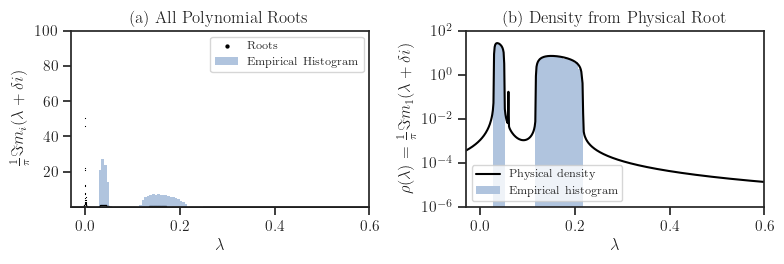


Changed af.delta_ladder to:
[1.e-05 2.e-05 3.e-05 4.e-05]



In [53]:
# Copy settigns so we can revert it later
orig_delta_ladder_size = af.inv_stieltjes_opt['delta_ladder_size']
orig_method = af.inv_stieltjes_opt['method']
orig_fit_degree = af.inv_stieltjes_opt['fit_degree']
set_delta_ladder(delta_ladder_size=1, method='direct')

x_min, x_max = config['xlim']

x_cand = numpy.linspace(x_min, x_max, 5000)
x_rho = numpy.linspace(x_min, x_max, 500)
bins = numpy.linspace(x_min, x_max, 200)

xlim = [x_min, x_max]
ylim = [1e-6, 1e2]

idx = start_idx
alpha = sizes[idx] / sizes[start_idx]
t_i = numpy.log(alpha)

rho = af.density(x_rho)
coeffs_i = deform_coeffs(af.coeffs, t_i, c0=af.ratio)

plot_candidate_comparison(x_cand, coeffs_i, x_rho, rho, bins, eigs[idx], xlim, ylim, '-init')

# Revert back to the original setting 
af.inv_stieltjes_opt['delta_ladder_size'] = orig_delta_ladder_size
af.inv_stieltjes_opt['method'] = orig_method
af.inv_stieltjes_opt['fit_degree'] = orig_fit_degree
set_delta_ladder(orig_delta_ladder_size, orig_method)


Changed af.delta_ladder to:
[1.e-05]


Changed af.delta_ladder to:
[1.e-05 2.e-05 3.e-05 4.e-05]

Max density: 6.226380970841126
Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/hessian2100k32k-candidates-final.pdf".


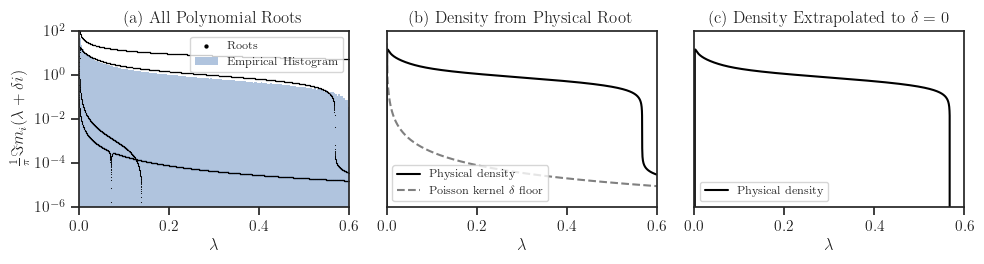


Changed af.delta_ladder to:
[1.e-05 2.e-05 3.e-05 4.e-05]



In [57]:
# Copy settigns so we can revert it later
orig_delta_ladder_size = af.inv_stieltjes_opt['delta_ladder_size']
orig_method = af.inv_stieltjes_opt['method']
orig_fit_degree = af.inv_stieltjes_opt['fit_degree']
set_delta_ladder(delta_ladder_size=1, method='direct')

x_min, x_max = config['xlim']

x_cand = numpy.linspace(5e-5, x_max, 5000)
x_rho = numpy.linspace(x_min, x_max, 500)
bins = numpy.linspace(x_min, x_max, 200)

# xlim = [x_min, x_max]
xlim = [0.0, 0.6]
ylim = [1e-6, 1e2]

end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]
idx = end_idx
alpha = sizes[idx] / sizes[start_idx]
t_i = numpy.log(alpha)

newton_opt = dict(
    dt_max=0.005,
    dt_min=1e-10,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=False,
    pair_enable=True,
    pair_gap_factor=10.0,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho_all = af.decompress(
    fd_sizes, x=x, kind='deformed', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=False, atom_eps=0.0,
    verbose=False, plot=False, latex=latex)
rho = rho_all[-1, :]

# Set to interpolate rho 
set_delta_ladder(delta_ladder_size=4, method='chebfit', fit_degree=2)

# Using extrapolation
rho_all2 = af.decompress(
    fd_sizes, x=x, kind='deformed', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=False, atom_eps=0.0,
    verbose=False, plot=False, latex=latex)
rho2 = rho_all2[-1, :]


coeffs_i = deform_coeffs(af.coeffs, t_i, c0=af.ratio)

plot_candidate_comparison(x_cand, coeffs_i, x, rho, bins, eigs[idx], xlim, ylim, '-final', cut=5e-5,
                          rho2=rho2)

# Revert back to the original setting 
af.inv_stieltjes_opt['delta_ladder_size'] = orig_delta_ladder_size
af.inv_stieltjes_opt['method'] = orig_method
af.inv_stieltjes_opt['fit_degree'] = orig_fit_degree
set_delta_ladder(orig_delta_ladder_size, orig_method)

In [55]:
xlim = [-0.02, 0.62]
ylim = [1e-6, 1e2]

coeffs_i = deform_coeffs(af.coeffs, t_i, c0=af.ratio)

plot_candidate_comparison(x_cand, coeffs_i, x, rho, bins, eigs[idx], xlim, ylim, '-final', cut=5e-5,
                          rho2=rho2)

# Revert back to the original setting 
af.inv_stieltjes_opt['delta_ladder_size'] = orig_delta_ladder_size
af.inv_stieltjes_opt['method'] = orig_method
af.inv_stieltjes_opt['fit_degree'] = orig_fit_degree
set_delta_ladder(orig_delta_ladder_size, orig_method)

Max density: 2.9514891843674844


IndexError: boolean index did not match indexed array along axis 0; size of axis is 500 but size of corresponding boolean axis is 2000